In [1]:
import matplotlib.pyplot as plt 
import numpy as np
import math
from constants import *


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


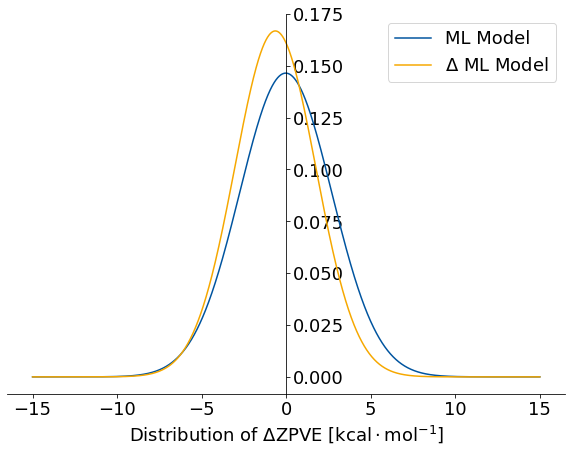

In [20]:
xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj,w}}{\partial a \partial b}\right)$',r'Distribution of $\Delta \left(\dfrac{\partial ^2 E^\mathrm{proj}}{\partial a \partial b}\right)$',
            r'Distribution of $\Delta \tilde{\nu}$ [$\mathrm{kcal \cdot mol^{-1}}$]']
limits = [[-15,15],[-2,2],[-5e-4,5e-4],[-2,2],[-8,8]]

# limits = [[-6.5e-4,6.5e-4]]
par =  ['ZPVE']
# xlabel = [r'Distribution of $\Delta \left(\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}\right)$']
i = 0
label = [r'ML Model',r'$\Delta$ ML Model']
j = 0
fontsize = 18

plt.style.use('rwth_colors.mplstyle')
def f(x,SD,mean):
    pi = math.pi
    #print(pi)
    #y = np.zeros(len(x))
    y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
    return y
list_plot = []
fig, ax = plt.subplots()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines["right"].set_position(("data", 0))

#ax.yaxis.set_ticks_position('right')
#plt.tick_params(axis='y', which='both', labelleft='off', labelright='on')
ax.yaxis.tick_right()
#ax.yaxis.set_ticks_position('both')
D_ZPVE = [list(np.genfromtxt('ZPVE_ML.txt')),list(np.genfromtxt('ZPVE_xTB.txt'))]
D_ZPVE_Delta = [list(np.genfromtxt('ZPVE_ML_Delta.txt')),list(np.genfromtxt('ZPVE_xTB_Delta.txt'))]

for element in [list(D_ZPVE),list(D_ZPVE_Delta)]:


    if par[i] == 'ZPVE':
        array_xtb = ( np.array(element[0]) - np.array(element[1]))*627.5
        arr_i = 0
        array_xtb = list(array_xtb)

        while arr_i < len(element[0]):
            if  element[1][arr_i]*627.5 > 1000. or element[1][arr_i] == 0.:
                array_xtb.pop(arr_i)
                element[0].pop(arr_i)
                element[1].pop(arr_i)

            else:
                arr_i += 1
        
    array_xtb = np.array(array_xtb)
    MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))
    
    dy2 = sum((array_xtb-array_xtb.mean())**2)
    SD = np.sqrt(dy2/len(array_xtb))
    SD = SD
    x = np.linspace(limits[i][0],limits[i][1],2000)
    #print(x)
    mean = array_xtb.mean()
    y = f(x,SD,mean)
    pl, = ax.plot(x,y,label = label[j])
    list_plot.append(pl)
    j+= 1


# plt.xlabel(r'Distribution of $\Delta \tilde{\nu}_\mathrm{n}$ [$\mathrm{cm}^{-1}$]')#[$\mathrm{cm}^{-1}$]' )
# plt.xlabel(r'$\Delta \mathrm{ZPE}~[\mathrm{eV}]$')#\lambda \left(\dfrac{\partial ^2 H^\mathrm{proj}}{\partial a \partial b}\right)$')#$ \Delta \mathrm{ZPE} [\mathrm{eV}]$')#$\dfrac{\partial ^2 H^\mathrm{proj,w}}{\partial a \partial b}$')#\sigma^\mathrm{corr}
if par[i] == 'wn':
    plt.xlabel(xlabel[i],fontsize = fontsize)
else:
    plt.xlabel(xlabel[i],fontsize = fontsize)

savename = f'ErrorDistNonZPE{par[i]}'

plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")
plt.legend()
plt.savefig(f'{savename}.png')
plt.savefig(f'{savename}.svg')
plt.savefig(f'{savename}.eps')

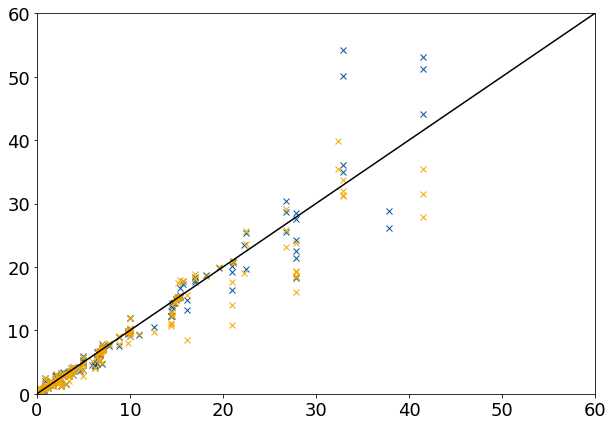

In [23]:
plt.plot(np.array(D_ZPVE[1])*627.5,np.array(D_ZPVE[0])*627.5,'x')

plt.plot(np.array(D_ZPVE_Delta[1])*627.5,np.array(D_ZPVE_Delta[0])*627.5,'x')
#plt.plot(np.array(D_ZPVE_Delta[1])*627.5,np.array(D_ZPVE_Delta[0])*627.5,'x')

plt.plot([0,60],[0,60],'k-')

plt.xlim([0,60])

plt.ylim([0,60])
plt.xlabel(r'ZPE$_\mathrm{xTB}$')
plt.ylabel(r'ZPE$_\mathrm{ML}$')

plt.savefig('ZPEvZPE.svg')
plt.savefig('ZPEvZPE.png')